<a href="https://colab.research.google.com/github/kelvintawe12/-PipelineTimeSeries_formative1/blob/glory-task1-analysis/Task_1_TimeSeries_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Time-series Preprocessing and Exploratory Analysis

## Task 1A

In [ ]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

## Load dataset + Parse dataset + sort

In [ ]:
CSV_PATH = "/content/Global_Market_Stress_and_Liquidity_Regimes.csv"

df = pd.read_csv(CSV_PATH)

assert "Date" in df.columns, "Missing 'Date' column. Check the dataset file."

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

print("Shape:", df.shape)
print("Date range:", df["Date"].min(), "->", df["Date"].max())
df.head()

Shape: (4150, 18)
Date range: 2014-10-17 00:00:00 -> 2026-02-25 00:00:00


,Date,Equities_US,Equities_Tech,Equities_Emerging,Bonds_LongTerm,Gold,Oil,Volatility_Index,Crypto_Bitcoin,Yield_Curve_Spread,High_Yield_Spread,Financial_Stress_Index,SPY_Drawdown,SPY_Rolling_Vol_30d,BTC_Rolling_Vol_30d,Stock_Bond_Corr_90d,SPY_RSI_14,GLD_RSI_14
0,2014-10-17,155.646973,85.314064,31.429737,89.155846,118.989998,250.000000,21.99,383.757996,1.83,4.68,0.1439,-0.061783,0.139503,0.747923,-0.362457,36.049689,59.589389
1,2014-10-18,155.646973,85.314064,31.429737,89.155846,118.989998,250.000000,21.99,391.441986,1.83,4.68,0.1439,-0.061783,0.137946,0.712420,-0.354625,36.049689,59.589389
2,2014-10-19,155.646973,85.314064,31.429737,89.155846,118.989998,250.000000,21.99,389.545990,1.83,4.68,0.1439,-0.061783,0.138038,0.669307,-0.357848,36.049689,59.589389
3,2014-10-20,157.158234,86.589172,31.522358,89.479881,119.800003,249.119995,18.57,382.845001,1.83,4.68,0.1439,-0.052673,0.142104,0.659277,-0.346507,43.472267,65.666002
4,2014-10-21,160.271683,88.864220,31.653578,88.765564,120.019997,250.399994,16.08,386.475006,1.85,4.50,0.1439,-0.033905,0.155200,0.654999,-0.368587,55.047992,67.112455


## Check Data Types + convert numeric columns safely

Date
1 days    4149
Name: count, dtype: int64


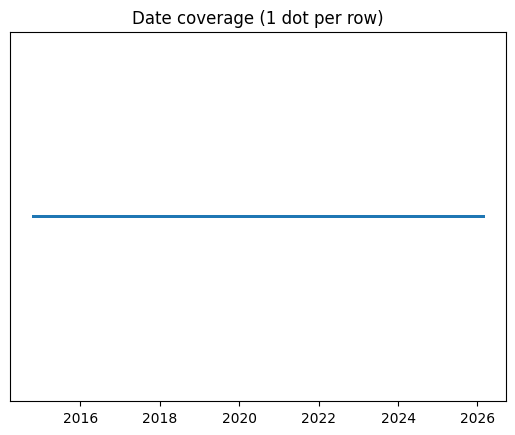

In [ ]:
num_cols = [c for c in df.columns if c != "Date"]
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce")

df.dtypes

## Frequency / granularity check (daily? gaps?)
diffs = df["Date"].diff().value_counts().head(10)
print(diffs)

plt.figure()
plt.plot(df["Date"], np.ones(len(df)), ".", markersize=2)
plt.title("Date coverage (1 dot per row)")
plt.yticks([])
plt.show()

## Missing Values report

In [ ]:
na_counts = df.isna().sum().sort_values(ascending=False)
na_counts.head(20)

# Forward-fill is common for macro series aligned to trading days
df[num_cols] = df[num_cols].ffill()

# Check remaining NAs
df.isna().sum().sort_values(ascending=False).head(20)

,0
Date,0
Equities_US,0
Equities_Tech,0
Equities_Emerging,0
Bonds_LongTerm,0
Gold,0
Oil,0
Volatility_Index,0
Crypto_Bitcoin,0
Yield_Curve_Spread,0


## Basic Summary Statistics

In [ ]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,4150,2020-06-21 12:00:00,2014-10-17 00:00:00,2017-08-19 06:00:00,2020-06-21 12:00:00,2023-04-24 18:00:00,2026-02-25 00:00:00,NaN
Equities_US,4150.0,339.648087,154.98082,215.668682,299.911621,424.768501,695.48999,146.176975
Equities_Tech,4150.0,266.527511,85.314064,136.069996,236.126472,362.213989,634.951965,149.557252
Equities_Emerging,4150.0,37.658429,22.630243,33.131978,36.881163,41.273785,62.619999,6.934079
Bonds_LongTerm,4150.0,101.464759,75.086784,89.968136,96.758888,108.931807,145.379349,15.907324
Gold,4150.0,168.576879,100.5,120.620003,159.009995,181.485004,495.899994,67.676339
Oil,4150.0,82.463019,17.040001,68.637499,77.839996,93.360001,250.399994,32.441848
Volatility_Index,4150.0,18.180248,9.14,13.49,16.389999,20.969999,82.690002,6.964474
Crypto_Bitcoin,4150.0,27768.735223,178.102997,3430.470337,11235.824219,43291.55957,124752.53125,32104.43185
Yield_Curve_Spread,4150.0,0.504814,-1.08,0.16,0.52,1.0,1.88,0.645936


### Destribution plot

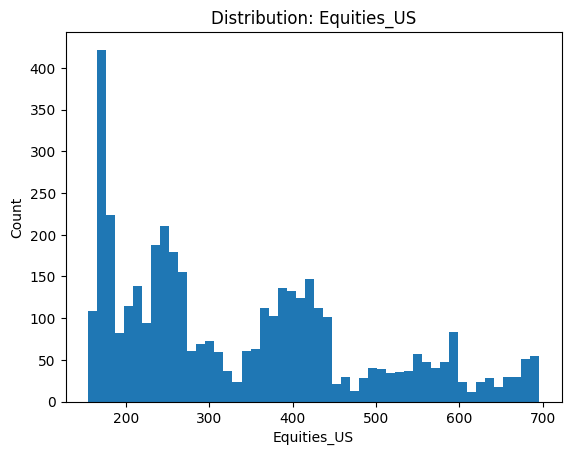

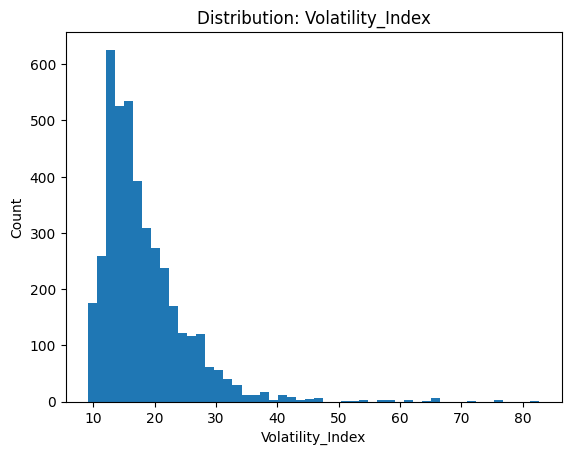

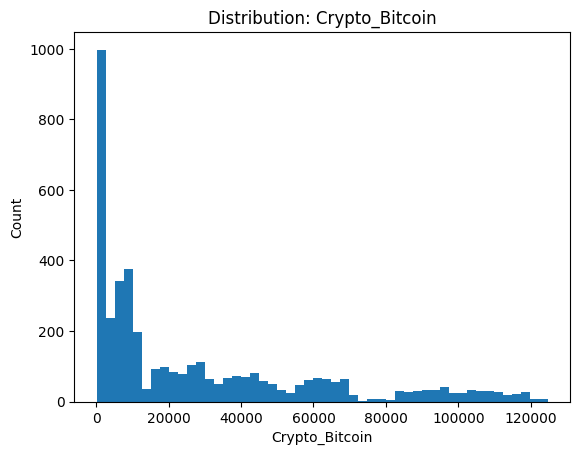

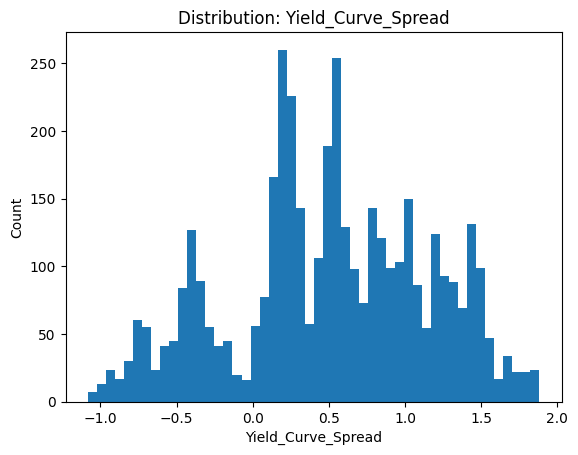

In [ ]:
key_cols = ["Equities_US", "Volatility_Index", "Crypto_Bitcoin", "Yield_Curve_Spread"]
key_cols = [c for c in key_cols if c in df.columns]

for c in key_cols:
    plt.figure()
    plt.hist(df[c].dropna(), bins=50)
    plt.title(f"Distribution: {c}")
    plt.xlabel(c)
    plt.ylabel("Count")
    plt.show()

#TASK 1B

### Create returns + target (next-day SPY return)

In [ ]:
assert "Equities_US" in df.columns, "Expected 'Equities_US' (SPY adjusted close)."

df["spy_ret_1d"] = df["Equities_US"].pct_change()
df["spy_ret_next"] = df["spy_ret_1d"].shift(-1)  # target

df = df.dropna(subset=["spy_ret_1d", "spy_ret_next"]).reset_index(drop=True)
df[["Date", "Equities_US", "spy_ret_1d", "spy_ret_next"]].head()

,Date,Equities_US,spy_ret_1d,spy_ret_next
0,2014-10-18,155.646973,0.000000,0.000000
1,2014-10-19,155.646973,0.000000,0.009710
2,2014-10-20,157.158234,0.009710,0.019811
3,2014-10-21,160.271683,0.019811,-0.007111
4,2014-10-22,159.132004,-0.007111,0.011625


### Feature engineering: lag features

In [ ]:
LAGS = [1, 5, 10]

for lag in LAGS:
    df[f"spy_ret_lag{lag}"] = df["spy_ret_1d"].shift(lag)

if "Volatility_Index" in df.columns:
    df["vix_lag1"] = df["Volatility_Index"].shift(1)
    df["vix_lag5"] = df["Volatility_Index"].shift(5)

df = df.dropna().reset_index(drop=True)
df.filter(regex="lag").head()

,spy_ret_lag1,spy_ret_lag5,spy_ret_lag10,vix_lag1,vix_lag5
0,-0.001374,0.011625,0.000000,16.040001,16.530001
1,0.011470,0.007695,0.000000,14.390000,16.110001
2,-0.001512,0.000000,0.009710,15.150000,16.110001
3,0.006411,0.000000,0.019811,14.520000,16.110001
4,0.011436,-0.001374,-0.007111,14.030000,16.040001


### Feature engineering: moving averages

In [ ]:
# Moving averages on SPY price and SPY returns
for w in [5, 20]:
    df[f"spy_ma{w}"] = df["Equities_US"].rolling(w).mean()
    df[f"spy_ret_ma{w}"] = df["spy_ret_1d"].rolling(w).mean()

# VIX moving averages
if "Volatility_Index" in df.columns:
    df["vix_ma20"] = df["Volatility_Index"].rolling(20).mean()

df = df.dropna().reset_index(drop=True)
df[["Date", "spy_ma20", "spy_ret_ma20"]].head()

,Date,spy_ma20,spy_ret_ma20
0,2014-12-05,170.646334,0.000917
1,2014-12-06,170.801593,0.000917
2,2014-12-07,170.951483,0.000885
3,2014-12-08,170.995253,0.000262
4,2014-12-09,171.046868,0.000309


### Q1 Visualization: trend/regimes (SPY over time)

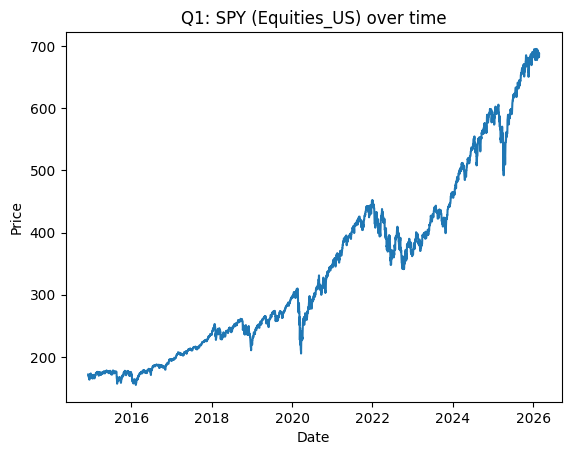

In [ ]:
plt.figure()
plt.plot(df["Date"], df["Equities_US"])
plt.title("Q1: SPY (Equities_US) over time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

### Q2 Visualization: VIX vs SPY daily returns

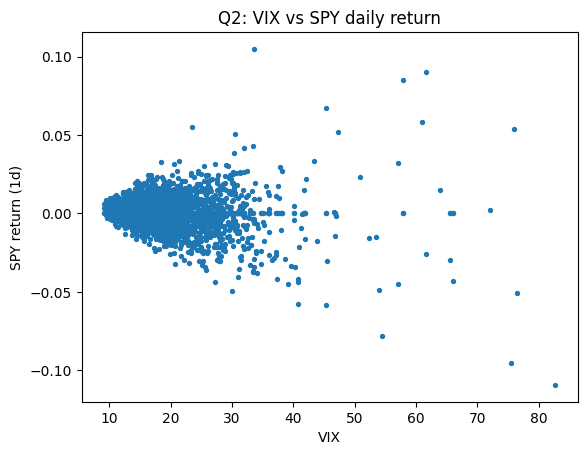

In [ ]:
if "Volatility_Index" in df.columns:
    plt.figure()
    plt.scatter(df["Volatility_Index"], df["spy_ret_1d"], s=8)
    plt.title("Q2: VIX vs SPY daily return")
    plt.xlabel("VIX")
    plt.ylabel("SPY return (1d)")
    plt.show()
else:
    print("Volatility_Index column not found.")

### Q3 Visualization (Lag): yesterday’s VIX vs next-day SPY return

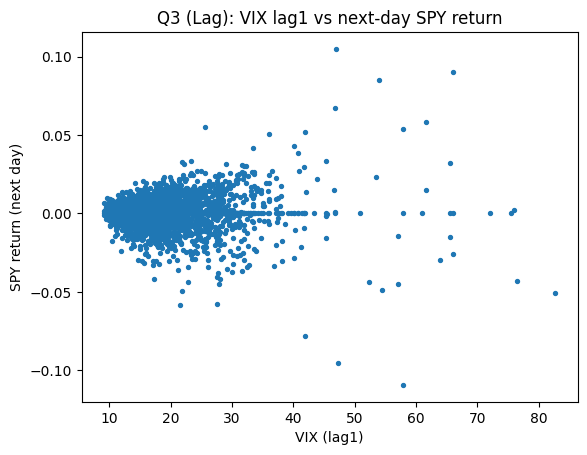

In [ ]:
if "vix_lag1" in df.columns:
    plt.figure()
    plt.scatter(df["vix_lag1"], df["spy_ret_next"], s=8)
    plt.title("Q3 (Lag): VIX lag1 vs next-day SPY return")
    plt.xlabel("VIX (lag1)")
    plt.ylabel("SPY return (next day)")
    plt.show()
else:
    print("vix_lag1 not found. Check Volatility_Index column.")

### Q4 Visualization (Moving Avg): VIX MA20 vs SPY drawdown (if exists)

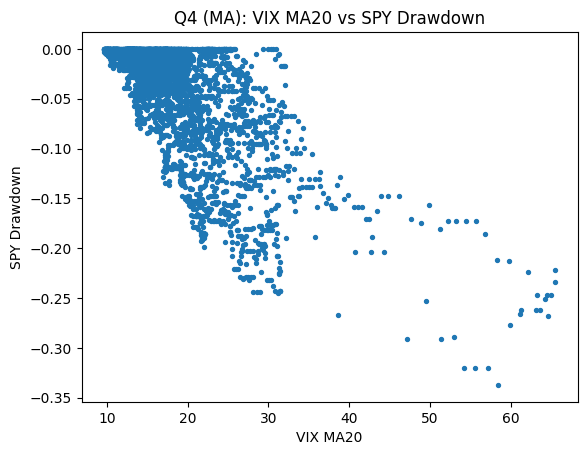

In [ ]:
if "vix_ma20" in df.columns and "SPY_Drawdown" in df.columns:
    plt.figure()
    plt.scatter(df["vix_ma20"], df["SPY_Drawdown"], s=8)
    plt.title("Q4 (MA): VIX MA20 vs SPY Drawdown")
    plt.xlabel("VIX MA20")
    plt.ylabel("SPY Drawdown")
    plt.show()
else:
    print("Missing vix_ma20 or SPY_Drawdown columns.")

### Q5 Visualization: Bonds lag vs next-day SPY return

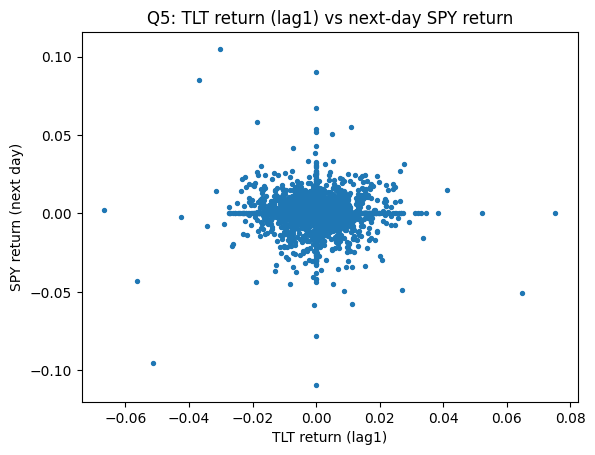

In [ ]:
if "Bonds_LongTerm" in df.columns:
    df["tlt_ret_1d"] = df["Bonds_LongTerm"].pct_change()
    df["tlt_ret_lag1"] = df["tlt_ret_1d"].shift(1)

    tmp = df.dropna(subset=["tlt_ret_lag1", "spy_ret_next"])

    plt.figure()
    plt.scatter(tmp["tlt_ret_lag1"], tmp["spy_ret_next"], s=8)
    plt.title("Q5: TLT return (lag1) vs next-day SPY return")
    plt.xlabel("TLT return (lag1)")
    plt.ylabel("SPY return (next day)")
    plt.show()
else:
    print("Bonds_LongTerm column not found.")

# TASK 1C - Modeling ( 2 Experiments + tunning)

### NaN Cleanup

In [ ]:
# Final cleanup: remove any remaining NaNs after pct_change/shift/rolling
print("NaNs before final drop:", df.isna().sum().sum())

df = df.dropna().reset_index(drop=True)

print("NaNs after final drop:", df.isna().sum().sum())
print("Final shape:", df.shape)

NaNs before final drop: 0
NaNs after final drop: 0
Final shape: (4098, 32)


### Build X/y for Modeling

In [ ]:
TARGET = "spy_ret_next"

X = df.drop(columns=["Date", TARGET])
y = df[TARGET].copy()

print("X shape:", X.shape, "y shape:", y.shape)

X shape: (4098, 30) y shape: (4098,)


### Time based split (No shuffle)

In [ ]:
split_idx = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train dates:", df["Date"].iloc[0], "->", df["Date"].iloc[split_idx-1])
print("Test dates:", df["Date"].iloc[split_idx], "->", df["Date"].iloc[-1])

Train: (3278, 30) Test: (820, 30)
Train dates: 2014-12-07 00:00:00 -> 2023-11-27 00:00:00
Test dates: 2023-11-28 00:00:00 -> 2026-02-24 00:00:00


### Experiment 1 Ridge + Tuning

In [ ]:
ridge_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

ridge_params = {"model__alpha": [0.1, 1.0, 10.0, 50.0]}

tscv = TimeSeriesSplit(n_splits=5)

ridge_search = GridSearchCV(
    ridge_pipe, ridge_params, cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1
)

ridge_search.fit(X_train, y_train)
best_ridge = ridge_search.best_estimator_

pred_ridge = best_ridge.predict(X_test)

def reg_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

ridge_mae, ridge_rmse, ridge_r2 = reg_metrics(y_test, pred_ridge)

print("Best Ridge params:", ridge_search.best_params_)
print("Ridge MAE:", ridge_mae, "RMSE:", ridge_rmse, "R2:", ridge_r2)

Best Ridge params: {'model__alpha': 50.0}
Ridge MAE: 0.005056516122477169 RMSE: 0.00844621145821505 R2: -0.04295261894764835


### Experiment 2 Random Forest + Tuning

In [ ]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

rf_params = {
    "n_estimators": [200, 500],
    "max_depth": [3, 5, None],
    "min_samples_leaf": [1, 5, 10]
}

rf_search = GridSearchCV(
    rf, rf_params, cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1
)

rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_

pred_rf = best_rf.predict(X_test)
rf_mae, rf_rmse, rf_r2 = reg_metrics(y_test, pred_rf)

print("Best RF params:", rf_search.best_params_)
print("RF MAE:", rf_mae, "RMSE:", rf_rmse, "R2:", rf_r2)

Best RF params: {'max_depth': 3, 'min_samples_leaf': 10, 'n_estimators': 500}
RF MAE: 0.004513220453300981 RMSE: 0.00827862826635796 R2: -0.0019762849411417704


### Experinment Result table

In [ ]:
exp_table = pd.DataFrame([
    {"experiment": "Exp1_Ridge", "model": "Ridge", "MAE": ridge_mae, "RMSE": ridge_rmse, "R2": ridge_r2},
    {"experiment": "Exp2_RF", "model": "RandomForest", "MAE": rf_mae, "RMSE": rf_rmse, "R2": rf_r2},
]).sort_values("MAE")

exp_table

,experiment,model,MAE,RMSE,R2
1,Exp2_RF,RandomForest,0.004513,0.008279,-0.001976
0,Exp1_Ridge,Ridge,0.005057,0.008446,-0.042953


In [ ]:
print("Rows:", len(df))
print("Any NaNs left?:", df.isna().sum().sum())
print("Saved files should exist: best_model_*.joblib and experiment_results.csv")

Rows: 4098
Any NaNs left?: 0
Saved files should exist: best_model_*.joblib and experiment_results.csv


### Save best model + Result

In [ ]:
best_model = best_ridge if ridge_mae <= rf_mae else best_rf
best_name = "ridge" if best_model is best_ridge else "random_forest"

joblib.dump(best_model, f"best_model_{best_name}.joblib")
exp_table.to_csv("experiment_results.csv", index=False)

print("Saved:", f"best_model_{best_name}.joblib")
print("Saved: experiment_results.csv")

Saved: best_model_random_forest.joblib
Saved: experiment_results.csv


# Task 1 – Time-Series Preprocessing & Modeling Summary

## Dataset Preparation
- Loaded the dataset and sorted it chronologically.
- Converted the `Date` column to datetime format.
- Verified daily time frequency and confirmed the time range (2014–2026).
- Checked and handled missing values (forward-fill + final removal of NaNs from lag/rolling features).

## Target Definition
- Computed daily SPY return (`spy_ret_1d`).
- Defined prediction target as **next-day SPY return (`spy_ret_next`)**.

## Feature Engineering
- Created lag features (e.g., `spy_ret_lag1`, `vix_lag1`).
- Created moving average features (e.g., `spy_ma20`, `vix_ma20`).
- Removed rows with insufficient historical data after feature creation.

## Exploratory Analysis
- Visualized SPY price trend and volatility regimes.
- Analyzed the relationship between VIX and SPY returns.
- Examined lag effects and moving average relationships.
- Explored cross-asset signals (e.g., bond returns vs equity returns).

## Modeling & Experiments
- Performed chronological train-test split (no shuffling).
- Trained and tuned two models:
  - Ridge Regression
  - Random Forest Regressor
- Evaluated models using MAE, RMSE, and R².
- Created an experiment comparison table.
- Saved the best-performing model for later integration.